In [ ]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import networkx as nx
import lib.ioFile as ioFile
import lib.powerfun as powerfun
import lib.biconnect as biconnect
import lib.cycle as cycle
import lib.graph as graph
import lib.parasLearn as parasLearn
import lib.subBase as subBase
import lib.subOptim as subOptim
import lib.plotGraph as plotGraph

# Load MATLAB file
file_name= 'matpower/test_data/DC_case14_.mat' #14, 118, 57, 30
# Access a variable inside the .mat file
_, phaseData, H, A= ioFile.read_mat_power(file_name, normalize= False)
m= H.shape[0]
n= H.shape[1]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
P= np.sum(np.abs(H), axis= 1, keepdims= True)/2
AL= subBase.incidence_to_link_connection(A)
# print(AL)
# print(np.abs(A@A.T))
linkPairs= []
# linkPairs= [(0, 2), (0, 3), (4, 2), (4, 3)]+linkPairs #special paper addition
# linkPairs= [(5, 3), (5, 6), (5, 8), (7, 3), (7, 6), (7, 8)]+linkPairs
# linkPairs= [(1, 4), (1, 6), (9, 4), (9, 6)]+linkPairs
linkPairs= [(1, 9), (1, 4), (6, 9), (6, 4)]+linkPairs # special paper
# linkPairs= [(6, 3), (6, 5), (6, 7), (8, 3), (8, 5), (8, 7)]+linkPairs
# linkPairs= [(8, 14), (8, 15), (16, 14), (16, 15)]+linkPairs
ALNew= subBase.disconnect_substation(AL, linkPairs)
newA, splitNodes= subBase.create_new_incidence_matrix(A, ALNew)
newH= newA*P
stdOfNoise= 1e-3
mNew= newH.shape[0]
newDataNp= powerfun.generate_random_power_flow(newH, m+1)
newDataNp= powerfun.add_noise_to_data(newDataNp, stdOfNoise)
biconnectedList, cosSim= biconnect.gen_biconnectedlist(newDataNp)
print(biconnectedList)
biconnected_components_dict= cycle.get_biconnected_components_dict(newDataNp, cosSim, biconnectedList)
predParas= parasLearn.paras_learning(biconnected_components_dict, newDataNp)
P= np.sum(np.abs(H), axis= 1, keepdims= True)/2
print((predParas/P).T)

LEN: 20
[[13], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19]]
Num of links: 19
Num of Detected links: 19
Circles Detected: 6
Run loops: 19
m*log(m): 55.94434060416236
Combine biconnected: 1

[[0.54291081 0.54297756 0.54295994 0.54295193 0.54305297 0.54295197
  0.54298685 0.54297784 0.5428833  0.54301389 0.54294012 0.54295688
  0.54295112 0.         0.54286758 0.54295863 0.54295939 0.54292592
  0.54295714 0.54293446]]


In [15]:
import itertools
def order_cycle_to_adjacency(m, cycleList):
    ALRes= np.zeros((m, m))
    cycleDic= dict()
    correct= True
    for cycle in cycleList:
        ALTemp= np.zeros((m, m))
        for linkIdx in range(len(cycle)):
            l1= cycle[linkIdx-1]
            l2= cycle[linkIdx]
            ALTemp[l1, l2]= 1
            ALTemp[l2, l1]= 1
        cycleSet= set(cycle)
        for visitedCycle in cycleDic.keys():
            visitedCycleSet= set(visitedCycle)
            sharedLinks= list(visitedCycleSet.intersection(cycleSet))
            ALTemp2= cycleDic[visitedCycle]
            if len(sharedLinks):
                subALRes= ALTemp2[sharedLinks, :][:, sharedLinks]
                subALTemp= ALTemp[sharedLinks, :][:, sharedLinks]
                if (np.abs(subALRes-subALTemp)).sum():
                    correct= False
        cycleDic[tuple(cycle)]= ALTemp
        for linkIdx in range(len(cycle)):
            l1= cycle[linkIdx-1]
            l2= cycle[linkIdx]
            ALRes[l1, l2]= 1
            ALRes[l2, l1]= 1
    return ALRes, correct
pathsList= []
for biconnected_components in biconnected_components_dict:
    cycleSpace= biconnected_components_dict[biconnected_components]
    for cycleT in cycleSpace:
        subAdjMatrix= AL[cycleT, :][:, cycleT]
        subIncidence= A[cycleT, :]
        steps= len(cycleT)-1
        nodeS= np.where(subIncidence[0, :]==1)[0][0]
        linkS= np.where(abs(subIncidence)[:, nodeS]== 1)[0]
        linkS= linkS.tolist()
        linkS.pop(linkS.index(0))
        paths = subOptim.get_all_paths(subAdjMatrix, start=0, steps=steps, singledir= linkS)
        pathsReal= [[cycleT[i] for i in path] for path in paths]
        if pathsReal!= []:
            pathsList.append(pathsReal)
        # print(pathsReal)
# print(pathsList)
combinations = itertools.product(*pathsList)
solutions= []
for combination in combinations:
    print(combination)
    ALTemp, correct= order_cycle_to_adjacency(m, combination)
    ground= ~((ALNew-ALTemp)<0).any()
    if correct:
        newATmp, splitNodesTmp= subBase.create_new_incidence_matrix(A, ALTemp)
        solutions.append((newATmp, splitNodesTmp))
    print(correct, ":", ground)

([16, 19, 12, 10, 17, 15], [18, 12, 11], [8, 14, 7], [3, 7, 14, 15, 17, 10, 9, 4], [0, 3, 6, 1], [2, 5, 3])
True : True


{4: [(4, [[0, 4], [3, 4]]), (14, [[4, 5], [1, 4]])]}


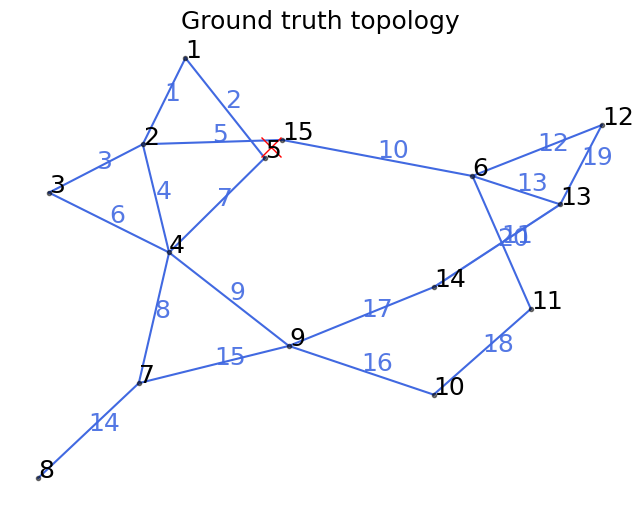

In [16]:
G, node_pair2id= graph.from_A_to_G(A)
newG, node_pair2idPre= graph.from_A_to_G(newA)
print(splitNodes)
title= "Ground truth topology"
plotGraph.plot_spring_layout_substation(G, newG, splitNodes, label_node= True, label_edge= True, stringT= title, node_pair2id= node_pair2idPre, seed= 1)

{4: [(4, [[0, 4], [3, 4]]), (14, [[4, 5], [1, 4]])], 6: [(6, [[6, 8], [3, 6]]), (15, [[6, 7]])]}


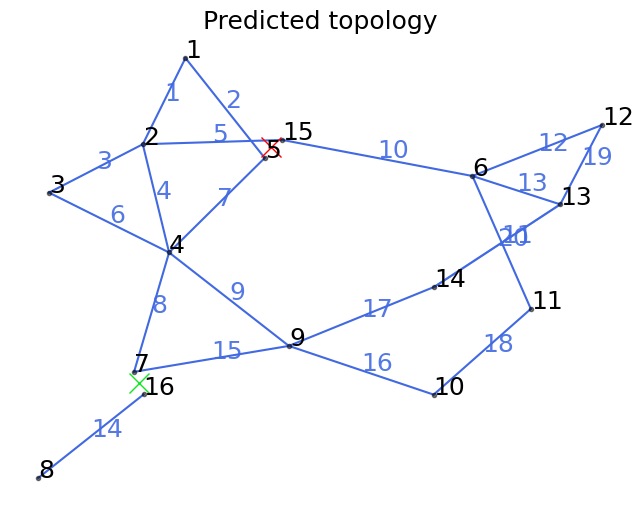

In [18]:
G, node_pair2id= graph.from_A_to_G(A)
newG, node_pair2idPre= graph.from_A_to_G(solutions[0][0])
print(splitNodesTmp)
# print(nx.has_path(newG, 8, 15))
title= "Predicted topology"
plotGraph.plot_spring_layout_substation(G, newG, solutions[0][1], label_node= True, label_edge= True, stringT= title, node_pair2id= node_pair2idPre, seed= 1)

In [54]:
# Example adjacency matrix (Modify it as per your network)
adj_matrix = np.array([
    [0, 1, 1, 1, 1, 0],
    [1, 0, 1, 1, 0, 1],
    [1, 1, 0, 1, 0, 1],
    [1, 1, 1, 0, 1, 0],
    [1, 0, 0, 1, 0, 0],
    [0, 1, 1, 0, 0, 1]
])

# Get all paths starting from node 0 with exactly 6 steps
paths = subOptim.get_all_paths(adj_matrix, start=0, steps=5)
print(paths)


[[0, 1, 5, 2, 3, 4], [0, 2, 5, 1, 3, 4], [0, 4, 3, 1, 5, 2], [0, 4, 3, 2, 5, 1]]
